## <b> <span style='color:#e61227'>|</span> Brain Tumor Detection With YOLOv8 and SCC </b> 

![](https://pub.mdpi-res.com/diagnostics/diagnostics-11-01856/article_deploy/html/images/diagnostics-11-01856-g002.png?1633696527)

## <b>1 <span style='color:#e61227'>|</span> Introduction</b> 

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>1.1 |</span></b> YOLOv8 and SCC-Enhanced Object Detection </b></p>
</div>

**YOLO(You Only Look Once)** is a widely used **object detection model** known for its speed and accuracy. We used **YOLOv8** to detect brain tumors in MRI images. To make it even better at spotting tumors, we added **SCC(Spatial and Channel Reconstruction Convolution)** — a module that helps the model pay attention to the right parts of the image and ignore less useful areas.

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>1.2 |</span></b> Study Aim </b></p>
</div>

The goal of this project is to accurately detect brain tumors in **MRI scans** by using **YOLOv8** enhanced with **SCC**, helping support early diagnosis and improving detection reliability. By training on a **custom dataset**, the model aims to assist in **early diagnosis** and **treatment planning**, ultimately improving patient outcomes.

## <b>2 <span style='color:#e61227'>|</span> Install And Import Essential Libreries</b> 

Here we install and import all the libraries needed for this project. **Ultralytics** gives us YOLOv8, **PyTorch** is the framework the model runs on, and libraries like **OpenCV** and **Matplotlib** are used for handling images and displaying results.

In [7]:
# Install Essential Libraries
!pip install ultralytics supervision -q
!pip install torch torchvision -q
from IPython.display import clear_output
clear_output()
print("Dependencies installed")

Dependencies installed


In [8]:
# Import Essential Libraries
import os, sys, warnings, shutil
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
import yaml
warnings.filterwarnings('ignore')

from ultralytics import YOLO
from ultralytics.nn.modules.conv import Conv
from ultralytics.nn.tasks import DetectionModel

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## <b>3 <span style='color:#e61227'>|</span> SCConv: Spatial and Channel Reconstruction Convolution</b> 

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>3.1 |</span></b> Spatial Reconstruction Unit (SRU)
 </b></p>
</div>

**SRU(Spatial Reconstruction Unit)** looks at the **feature map** and decides which **spatial locations** are useful and which are not. **Useful regions** are kept as-it-is, while less important areas are reduced. This helps the model to focus on the tumor region rather than the background.

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>3.2 |</span></b> Channel Reconstruction Unit (CRU)
 </b></p>
</div>

**CRU(Channel Reconstruction Unit)** works on the **feature channels** instead of spatial locations. It figures out which channels carry the most **useful information** and boosts them while reducing the less relevant ones. This helps the model better distinguish between different tumor types.

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>3.3 |</span></b> SCC Module
 </b></p>
</div>

The **SCC(Spatial and Channel Reconstruction Convolution)** module combines both **SRU(Spatial Reconstruction Unit)** and **CRU(Channel Reconstruction Unit)** together. The input goes through SRU first, then later to CRU, and the result is then added back to the original input. This full module is plugged into YOLOv8 to improve the **quality of features** extracted.

In [9]:
# SCConv: Spatial and Channel Reconstruction Convolution
import torch
import torch.nn as nn
import torch.nn.functional as F


class SRU(nn.Module):
    """Spatial Reconstruction Unit — suppresses spatial redundancy."""
    def __init__(self, channels, group_num=4, gate_thr=0.5):
        super().__init__()
        self.gate_thr = gate_thr
        # GroupNorm requires groups to divide channels evenly
        group_num = min(group_num, channels)
        while channels % group_num != 0:
            group_num -= 1
        self.norm = nn.GroupNorm(group_num, channels)

    def forward(self, x):
        normed = self.norm(x)
        w = torch.sigmoid(normed)
        x_info = x * (w >= self.gate_thr).float()
        x_redu = x * (w <  self.gate_thr).float()
        return x_info + x_redu * w


class CRU(nn.Module):
    """Channel Reconstruction Unit — suppresses channel redundancy."""
    def __init__(self, channels, alpha=0.5, squeeze_ratio=2):
        super().__init__()
        self.upper_ch = max(int(channels * alpha), 1)
        self.lower_ch = max(channels - self.upper_ch, 1)
        mid_ch = max(channels // squeeze_ratio, 1)

        # Upper branch: GWC + PWC
        groups = max(self.upper_ch // 16, 1)
        # groups must divide upper_ch
        while self.upper_ch % groups != 0:
            groups -= 1
        self.gwc  = nn.Conv2d(self.upper_ch, mid_ch, 3, padding=1, groups=groups, bias=False)
        self.pwc1 = nn.Conv2d(self.upper_ch, mid_ch, 1, bias=False)

        # Lower branch: PWC
        self.pwc2 = nn.Conv2d(self.lower_ch, mid_ch, 1, bias=False)

        # Fusion
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.bn       = nn.BatchNorm2d(mid_ch)
        self.relu     = nn.ReLU(inplace=True)
        self.out_conv = nn.Conv2d(mid_ch, channels, 1, bias=False)

    def forward(self, x):
        x_upper = x[:, :self.upper_ch]
        x_lower = x[:, self.upper_ch:]

        y1 = self.gwc(x_upper) + self.pwc1(x_upper)
        y2 = self.pwc2(x_lower)

        s1 = self.pool(y1)
        s2 = self.pool(y2)
        w  = torch.softmax(torch.cat([s1, s2], dim=1), dim=1)
        w1, w2 = w[:, :s1.shape[1]], w[:, s1.shape[1]:]

        fused = y1 * w1 + y2 * w2
        fused = self.relu(self.bn(fused))
        return self.out_conv(fused)


class SCConv(nn.Module):
    """SCConv = SRU → CRU with residual connection."""
    def __init__(self, in_channels, out_channels,
                 group_num=4, gate_thr=0.5, alpha=0.5, squeeze_ratio=2):
        super().__init__()
        self.sru = SRU(in_channels, group_num=group_num, gate_thr=gate_thr)
        self.cru = CRU(in_channels, alpha=alpha, squeeze_ratio=squeeze_ratio)
        self.bn  = nn.BatchNorm2d(in_channels)
        self.act = nn.SiLU(inplace=True)

        # Channel projection if in != out
        self.proj = (nn.Sequential(
                         nn.Conv2d(in_channels, out_channels, 1, bias=False),
                         nn.BatchNorm2d(out_channels))
                     if in_channels != out_channels else nn.Identity())

    def forward(self, x):
        out = self.sru(x)
        out = self.cru(out)
        out = self.act(self.bn(out)) + x   # residual (pre-projection)
        return self.proj(out)


# ── Sanity check ──
for ch in [128, 256, 512]:
    _x   = torch.randn(2, ch, 40, 40)
    _scc = SCConv(ch, ch)
    _out = _scc(_x)
    assert _out.shape == _x.shape, f"Shape mismatch at ch={ch}: {_out.shape}"
    print(f"  SCConv({ch}) → shape {tuple(_out.shape)}  params={sum(p.numel() for p in _scc.parameters()):,}")


  SCConv(128) → shape (2, 128, 40, 40)  params=26,240
  SCConv(256) → shape (2, 256, 40, 40)  params=85,248
  SCConv(512) → shape (2, 512, 40, 40)  params=301,568


## <b>4 <span style='color:#e61227'>|</span> Integration with YOLOv8</b> 

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>4.1 |</span></b> Injecting SCConv into the YOLOv8 Head
 </b></p>
</div>

We add SCC to the **detection head** of YOLOv8, which is the part responsible for making the final predictions. The **C2f blocks** in the head are wrapped with SCC so the **features** get refined just before the model outputs its detections. The detection head predicts the **bounding boxes** and **type** of the tumor.

In [10]:
# SCC-YOLOv8: Inject SCConv into YOLOv8 head C2f layers
import torch.nn as nn
from ultralytics import YOLO
from ultralytics.nn.modules import C2f


class C2fWithSCConv(nn.Module):
    """Wraps an existing C2f block, appending SCConv after it."""
    def __init__(self, c2f_block):
        super().__init__()
        self.c2f = c2f_block
        # Infer output channels from C2f's final conv
        out_ch = c2f_block.cv2.conv.out_channels
        self.scconv = SCConv(out_ch, out_ch)

    def forward(self, x):
        return self.scconv(self.c2f(x))


def inject_scconv_into_head(yolo_model):
    """
    Replace C2f layers in the YOLOv8 HEAD with C2fWithSCConv.
    Head = layers 10–21 (after backbone ends at layer 9/SPPF).
    """
    seq = yolo_model.model.model   # the nn.Sequential of all layers

    HEAD_START = 10   # first head layer index (after SPPF at index 9)
    n_injected = 0
    injection_log = []

    for idx in range(HEAD_START, len(seq)):
        layer = seq[idx]

        # FIX: check the layer itself, not its children
        if isinstance(layer, C2f):
            out_ch = layer.cv2.conv.out_channels
            seq[idx] = C2fWithSCConv(layer)   # replace in-place
            n_injected += 1
            injection_log.append((idx, out_ch))

    # Summary
    if n_injected == 0:
        print("No C2f found in head — printing layer types for debug:")
        for i, layer in enumerate(seq):
            print(f"  [{i:2d}] {type(layer).__name__}")
    else:
        print(f"SCConv injected after {n_injected} C2f block(s):")
        for idx, ch in injection_log:
            print(f"   Layer [{idx}] C2f({ch}ch) → C2fWithSCConv({ch}ch)")

    return yolo_model


# ── Load & inject ──────────────────────────────────────────
base_model = YOLO('yolov8n.pt')
scc_model  = inject_scconv_into_head(base_model)

# ── Parameter count (call BEFORE .train() which triggers eval mode)
all_params       = sum(p.numel() for p in scc_model.model.parameters())
# Unfreeze to count trainable properly
for p in scc_model.model.parameters():
    p.requires_grad_(True)
trainable_params = sum(p.numel() for p in scc_model.model.parameters() if p.requires_grad)

print(f"\n   Total parameters  : {all_params:,}")
print(f"   Trainable params  : {trainable_params:,}")
print(f"   SCConv overhead   : +{all_params - 3_157_200:,} params vs baseline YOLOv8n")

SCConv injected after 4 C2f block(s):
   Layer [12] C2f(128ch) → C2fWithSCConv(128ch)
   Layer [15] C2f(64ch) → C2fWithSCConv(64ch)
   Layer [18] C2f(128ch) → C2fWithSCConv(128ch)
   Layer [21] C2f(256ch) → C2fWithSCConv(256ch)

   Total parameters  : 3,303,952
   Trainable params  : 3,303,952
   SCConv overhead   : +146,752 params vs baseline YOLOv8n


<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227'>4.2 |</span></b>  Training Setup and Hyperparameters </b></p>
</div>

Both the **SCC-YOLOv8** and the standard **YOLOv8** are trained using the same settings so the comparison is fair. We use **SGD** as the optimizer, train for up to **100 epochs** with early stopping, and apply **data augmentation** to help the model generalize better on unseen MRI images. 

## Key hyperparameters of the model include:

- Batch Size: Number of images processed in one iteration. Affects memory usage and convergence speed.
- Epochs: Number of complete passes through the training dataset.
- Optimizer: Algorithm used to minimize the loss function. Choices include SGD, Adam, and others.
- Patience: Number of epochs with no improvement after which training is stopped early.
- Learning Rate: Controls the step size during optimization. A lower learning rate ensures slower, more stable updates.


In [7]:
# Training — SCC-YOLOv8 on Brain Tumor Dataset

YAML_PATH   = '/kaggle/input/datasets/gollasaivivek/brain-tumor/dataset/data.yaml'
EPOCHS      = 30          
BATCH_SIZE  = 8           
IMG_SIZE    = 640
PROJECT     = '/kaggle/working/runs/scc_yolo'
RUN_NAME    = 'brain_tumor_sccyolo'

results = scc_model.train(
    data        = YAML_PATH,
    epochs      = EPOCHS,
    batch       = BATCH_SIZE,
    imgsz       = IMG_SIZE,
    optimizer   = 'SGD',
    lr0         = 0.01,
    momentum    = 0.937,
    weight_decay= 0.0005,
    patience    = 20,           # early stopping
    augment     = True,
    mosaic      = 1.0,
    mixup       = 0.1,
    copy_paste  = 0.1,
    project     = PROJECT,
    name        = RUN_NAME,
    exist_ok    = True,
    device      = 0,
    verbose     = True,
)

print("\nTraining complete!")
print(f"Best weights saved to: {PROJECT}/{RUN_NAME}/weights/best.pt")

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/gollasaivivek/brain-tumor/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_sccyolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, 

In [8]:
# Training — Baseline YOLOv8 on Brain Tumor Dataset

from ultralytics import YOLO
import torch

baseline = YOLO('yolov8n.pt')

baseline.train(
    data        = YAML_PATH,                    
    epochs      = EPOCHS,
    batch       = BATCH_SIZE,
    imgsz       = IMG_SIZE,
    optimizer   = 'SGD',
    lr0         = 0.01,
    momentum    = 0.937,
    patience    = 20,
    project     = '/kaggle/working/runs/baseline_yolo',  
    name        = 'brain_tumor_baseline',
    exist_ok    = True,
    device      = 0,                              
    verbose     = True,
)

print("Baseline training complete!")

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/gollasaivivek/brain-tumor/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_baseline, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD

## <b>5 <span style='color:#e61227'>|</span> Evaluation and Results</b> 

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>5.1 |</span></b> Comparing Both Models
 </b></p>
</div>

After training, we load the best saved weights for both models and run them on the test set. This gives us metrics like **Mean Average Precision(mAP)**, **precision**, and **recall** so we can directly compare how well SCC-YOLOv8 does versus the standard baseline.

- Precision: Ratio of correctly predicted positive observations to total predicted positives. High precision indicates fewer false positives.
- Recall: Ratio of correctly predicted positive observations to all actual positives. High recall indicates fewer false negatives.
- mAP50: Mean Average Precision at 50% IoU. Measures accuracy at a single IoU threshold.
- mAP50-95: Mean Average Precision across multiple IoU thresholds, providing a more comprehensive measure of performance.
- IoU (Intersection Over Union): Measures overlap between predicted and ground truth bounding boxes.

In [9]:
# Evaluate & Compare — mAP50, mAP50:95, Precision, Recall

# Load best weights
best_scc      = YOLO(f'{PROJECT}/{RUN_NAME}/weights/best.pt')
best_baseline = YOLO('/kaggle/working/runs/baseline_yolo/brain_tumor_baseline/weights/best.pt')

# Run validation on test split
metrics_scc  = best_scc.val(data=YAML_PATH, split='test')
metrics_base = best_baseline.val(data=YAML_PATH, split='test')

import pandas as pd

results_table = pd.DataFrame({
    'Model': ['YOLOv8n (Baseline)', 'SCC-YOLOv8 (Ours)'],
    'mAP50':     [round(metrics_base.box.map50, 4),
                  round(metrics_scc.box.map50,  4)],
    'mAP50:95':  [round(metrics_base.box.map,   4),
                  round(metrics_scc.box.map,     4)],
    'Precision': [round(metrics_base.box.mp,     4),
                  round(metrics_scc.box.mp,       4)],
    'Recall':    [round(metrics_base.box.mr,     4),
                  round(metrics_scc.box.mr,       4)],
})

print("\n Performance Comparison (Test Set)")
print("=" * 60)
print(results_table.to_string(index=False))

# Highlight improvement
delta_map50 = results_table['mAP50'][1] - results_table['mAP50'][0]
print(f"\n mAP50 improvement with SCConv: +{delta_map50:.4f}")

Ultralytics 8.4.16 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.3±1.1 MB/s, size: 32.6 KB)
val: Scanning /kaggle/input/datasets/gollasaivivek/brain-tumor/dataset/labels/test... 308 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 308/308 235.1it/s 1.3s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/gollasaivivek/brain-tumor/dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 5.6it/s 3.6s0.1s
                   all        308        308      0.901      0.876      0.916      0.668
                glioma        159        159      0.815      0.736      0.799      0.514
            meningioma         62         62      0.952      0.984       0.98      0.812
             pituitary         87         87      0.938      0

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>5.2 |</span></b> Training Curves
 </b></p>
</div>

Here we plot the **loss** and **mAP** over each epoch for both models. These graphs help us see how training progressed and how well each model improved over time.

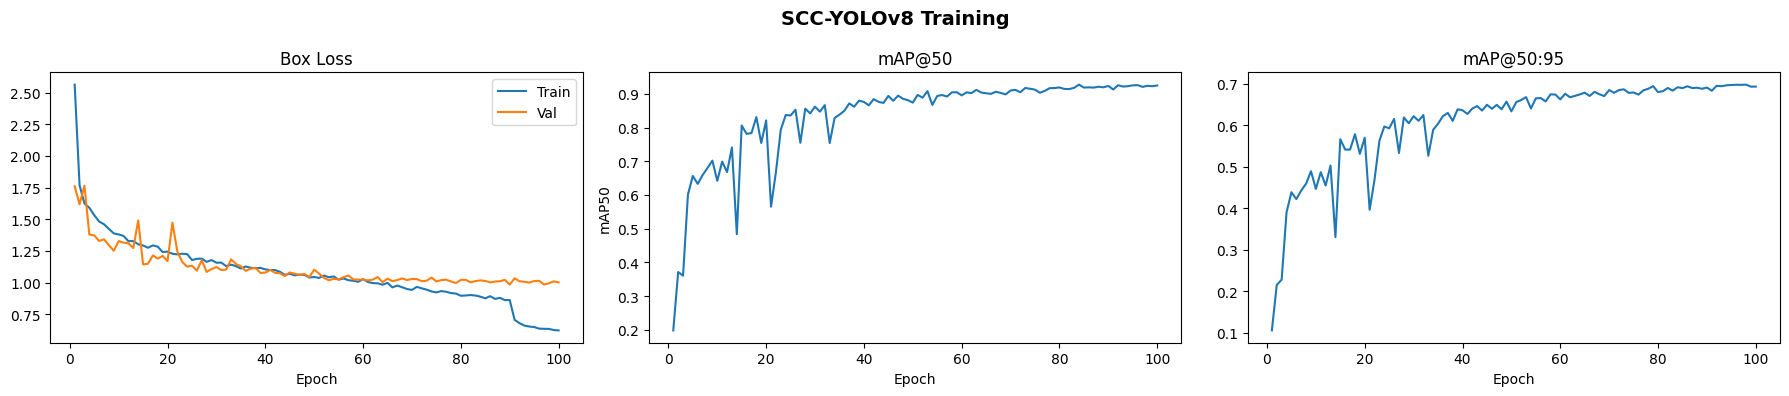

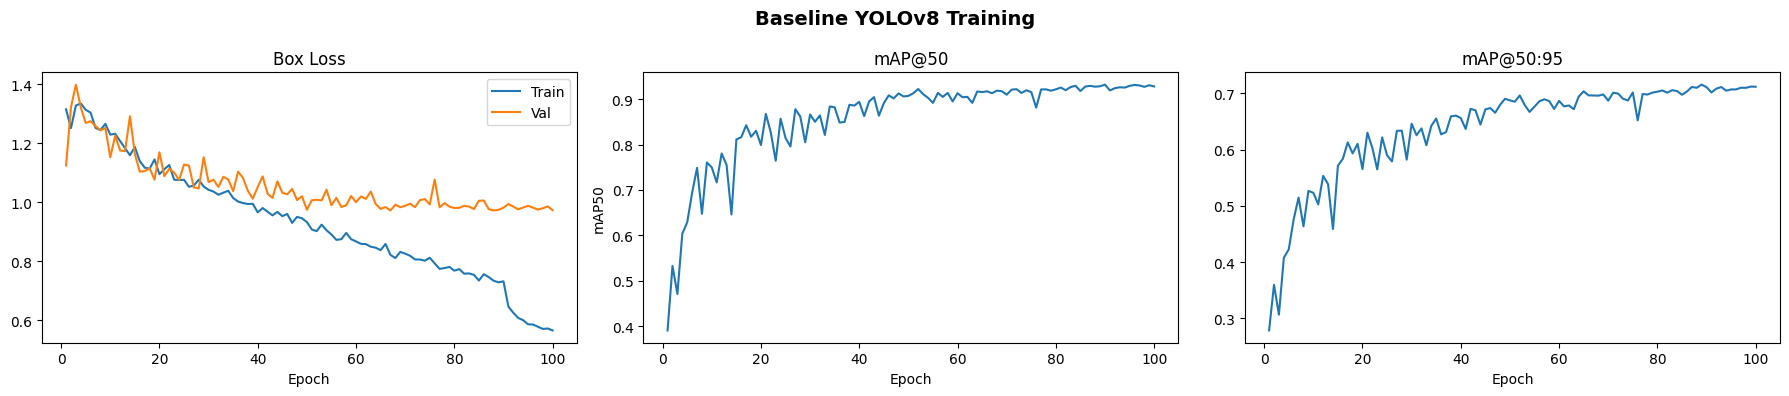

In [10]:
# Visualize Training Curves (Loss + mAP)

import pandas as pd
import matplotlib.pyplot as plt

def plot_training_curves(run_dir, title):
    csv_path = os.path.join(run_dir, 'results.csv')
    if not os.path.exists(csv_path):
        print(f"CSV not found: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Box loss
    axes[0].plot(df['epoch'], df['train/box_loss'], label='Train')
    axes[0].plot(df['epoch'], df['val/box_loss'],   label='Val')
    axes[0].set_title('Box Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # mAP50
    axes[1].plot(df['epoch'], df['metrics/mAP50(B)'])
    axes[1].set_title('mAP@50')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP50')

    # mAP50-95
    axes[2].plot(df['epoch'], df['metrics/mAP50-95(B)'])
    axes[2].set_title('mAP@50:95')
    axes[2].set_xlabel('Epoch')

    plt.tight_layout()
    plt.savefig(os.path.join(run_dir, 'training_curves.png'), dpi=150)
    plt.show()

# SCC-YOLOv8
plot_training_curves(
    f'{PROJECT}/{RUN_NAME}',
    'SCC-YOLOv8 Training'
)

# Baseline YOLOv8
plot_training_curves(
    '/kaggle/working/runs/baseline_yolo/brain_tumor_baseline',
    'Baseline YOLOv8 Training'
)

<div style="color:white;display:fill;border-radius:8px;
            background-color:#03112A;font-size:150%;
            letter-spacing:1.0px;background-image: url(https://i.imgur.com/GVd0La1.png)">
    <p style="padding: 8px;color:white;"><b><b><span style='color:#e61227''>5.3 |</span></b> Sample Predictions on Test Images
 </b></p>
</div>

We run the trained **SCC-YOLOv8** model on a few test MRI images and draw the predicted **bounding boxes**. Each tumor type is shown in a **different color** so it's easy to visually check whether the model is detecting the right regions.

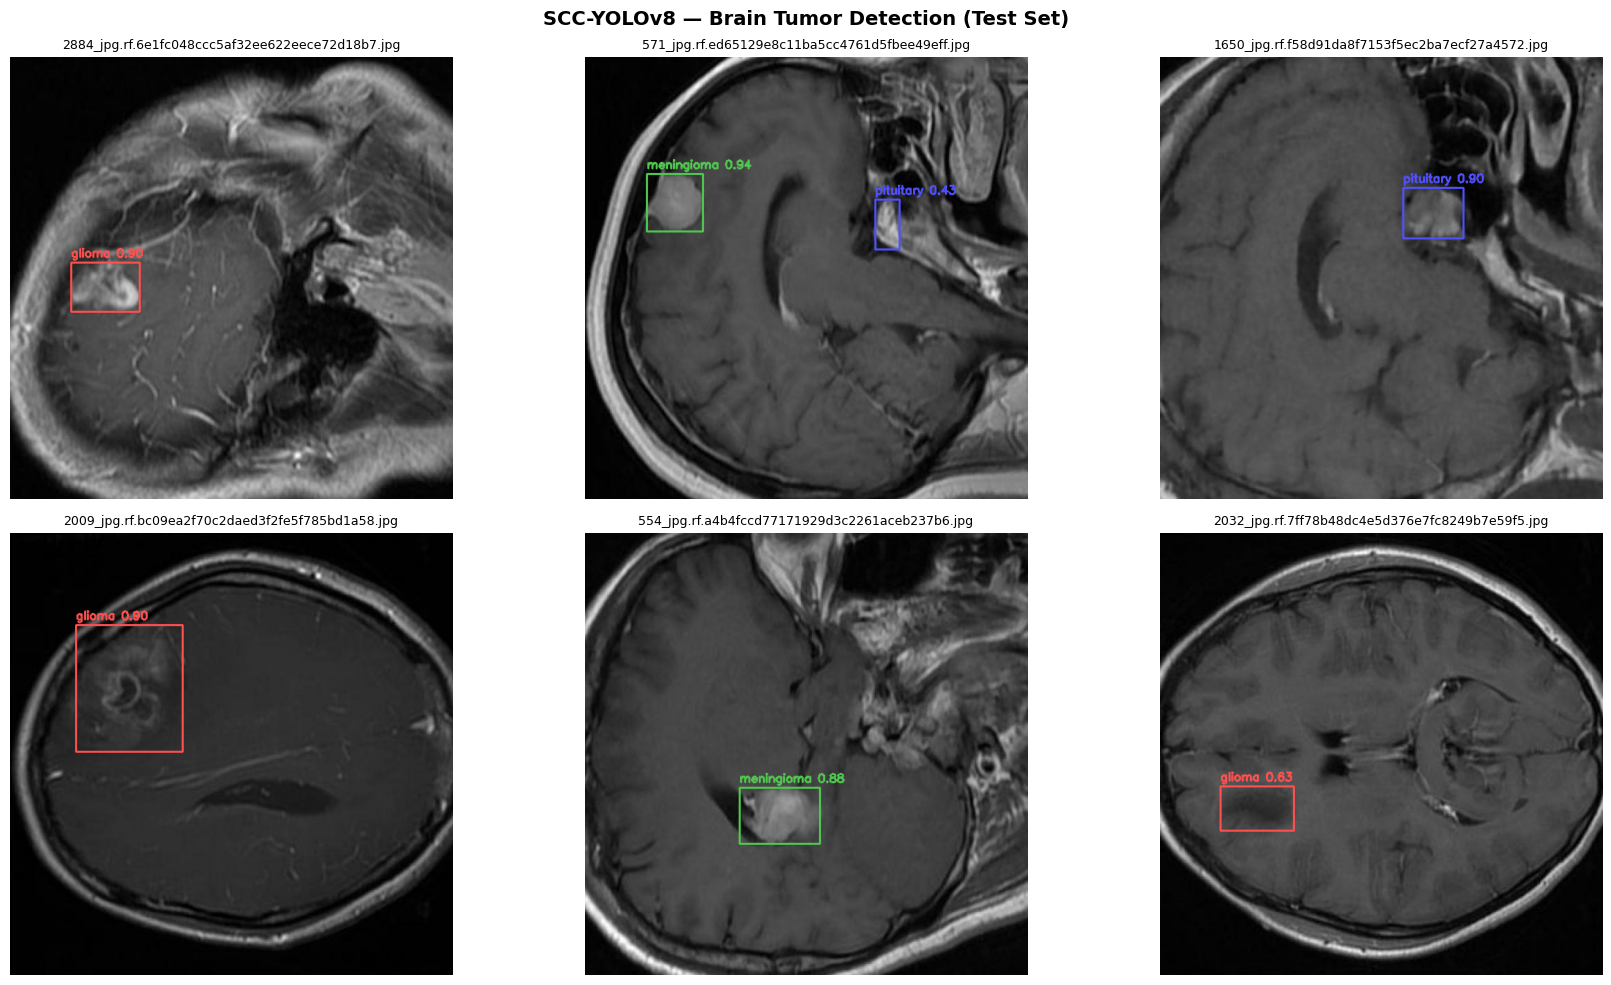

In [11]:
# Inference — visualize predictions on test images

import random, cv2
from pathlib import Path

test_img_dir = '/kaggle/input/datasets/gollasaivivek/brain-tumor/dataset/images/test'
test_imgs    = list(Path(test_img_dir).glob('*.jpg'))[:6]  # show 6

if not test_imgs:
    test_imgs = list(Path(test_img_dir).glob('*.png'))[:6]

CLASS_COLORS = {0: (255, 80,  80),   # glioma      — red
                1: (80,  200, 80),   # meningioma  — green
                2: (80,  80,  255)}  # pituitary   — blue
CLASS_NAMES  = ['glioma', 'meningioma', 'pituitary']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, test_imgs):
    result = best_scc.predict(str(img_path), conf=0.25, verbose=False)[0]
    img    = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)

    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        color = CLASS_COLORS.get(cls, (255, 255, 255))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f"{CLASS_NAMES[cls]} {conf:.2f}"
        cv2.putText(img, label, (x1, max(y1-8, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    ax.imshow(img)
    ax.set_title(Path(img_path).name, fontsize=9)
    ax.axis('off')

plt.suptitle('SCC-YOLOv8 — Brain Tumor Detection (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/scc_yolo_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


 Per-Class AP50 Comparison
     Class  Baseline AP50  SCC-YOLO AP50   Delta
    glioma         0.7914         0.7992  0.0078
meningioma         0.9758         0.9799  0.0041
 pituitary         0.9773         0.9687 -0.0085


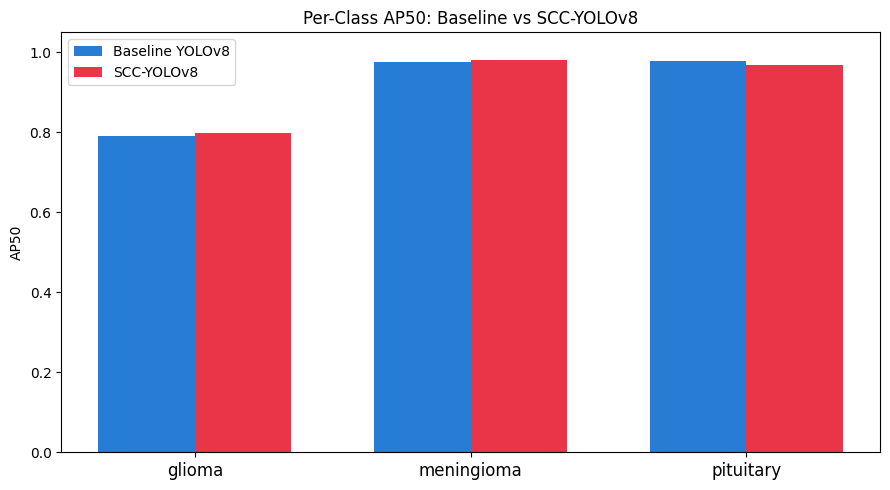

In [12]:
# Per-Class mAP breakdown

class_names = ['glioma', 'meningioma', 'pituitary']

ap_scc  = metrics_scc.box.ap50          # list of AP50 per class
ap_base = metrics_base.box.ap50

per_class = pd.DataFrame({
    'Class':         class_names,
    'Baseline AP50': [round(v, 4) for v in ap_base],
    'SCC-YOLO AP50': [round(v, 4) for v in ap_scc],
    'Delta':         [round(a - b, 4) for a, b in zip(ap_scc, ap_base)]
})

print("\n Per-Class AP50 Comparison")
print(per_class.to_string(index=False))

# Bar chart
x = np.arange(len(class_names))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, per_class['Baseline AP50'], w, label='Baseline YOLOv8', color='#0066cc', alpha=0.85)
ax.bar(x + w/2, per_class['SCC-YOLO AP50'], w, label='SCC-YOLOv8',      color='#e61227', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(class_names, fontsize=12)
ax.set_ylabel('AP50'); ax.set_title('Per-Class AP50: Baseline vs SCC-YOLOv8')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('/kaggle/working/per_class_ap50.png', dpi=150)
plt.show()

## <b>6 <span style='color:#e61227'>|</span> Model Deployment using Gradio</b>

To demonstrate the practical usability of the proposed **SCC-YOLOv8** model, an interactive user interface was developed using **Gradio**.  
This interface allows users to upload **MRI brain images** and automatically detects and localizes tumors such as *glioma*, *meningioma*, and *pituitary tumors*.

The Gradio-based deployment enables:
- Easy image upload through a web interface  
- Real-time tumor detection and localization  
- Visualization of bounding boxes with confidence scores  

⚠️ **Note:** Due to runtime and asynchronous execution limitations in platforms like Kaggle, this Gradio interface is intended for deployment and demonstration in environments such as **Google Colab** or **local systems**, where full web-based interaction is supported.

This deployment step highlights the real-world applicability of the proposed SCC-enhanced YOLOv8 framework for assisting medical professionals in automated brain tumor detection.

In [32]:
# Gradio Interface — Upload MRI and detect tumors
!pip install gradio -q

import gradio as gr
from PIL import Image

CLASS_COLORS = {
    0: (255, 80,  80),   # glioma      — red
    1: (80,  200, 80),   # meningioma  — green
    2: (80,  80,  255)   # pituitary   — blue
}
CLASS_NAMES = ['glioma', 'meningioma', 'pituitary']

def detect_tumor(image):
    img = np.array(image)
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    results = best_scc.predict(img_bgr, conf=0.25, verbose=False)[0]

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        color = CLASS_COLORS.get(cls, (255, 255, 255))
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
        label = f"{CLASS_NAMES[cls]} {conf:.2f}"
        cv2.putText(img, label, (x1, max(y1 - 8, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    if len(results.boxes) == 0:
        return Image.fromarray(img), "No tumor detected."

    detected = [f"{CLASS_NAMES[int(b.cls[0])]} ({float(b.conf[0]):.2f})" for b in results.boxes]
    label_text = "Detected: " + ", ".join(detected)
    return Image.fromarray(img), label_text


interface = gr.Interface(
    fn=detect_tumor,
    inputs=gr.Image(type="pil", label="Upload MRI Image"),
    outputs=[
        gr.Image(type="pil", label="Detection Result"),
        gr.Textbox(label="Detected Tumors")
    ],
    title="Brain Tumor Detection — SCC-YOLOv8",
    description="Upload an MRI image and the model will detect and label any brain tumors found.",
    allow_flagging="never"
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7875
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://0b2932719ff455479d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
